In [1]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
x = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [4]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [5]:
y

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [9]:
print(np.sum(y['num']==2))
print(np.sum(y['num']==1))
print(np.sum(y['num']==0))

36
55
164


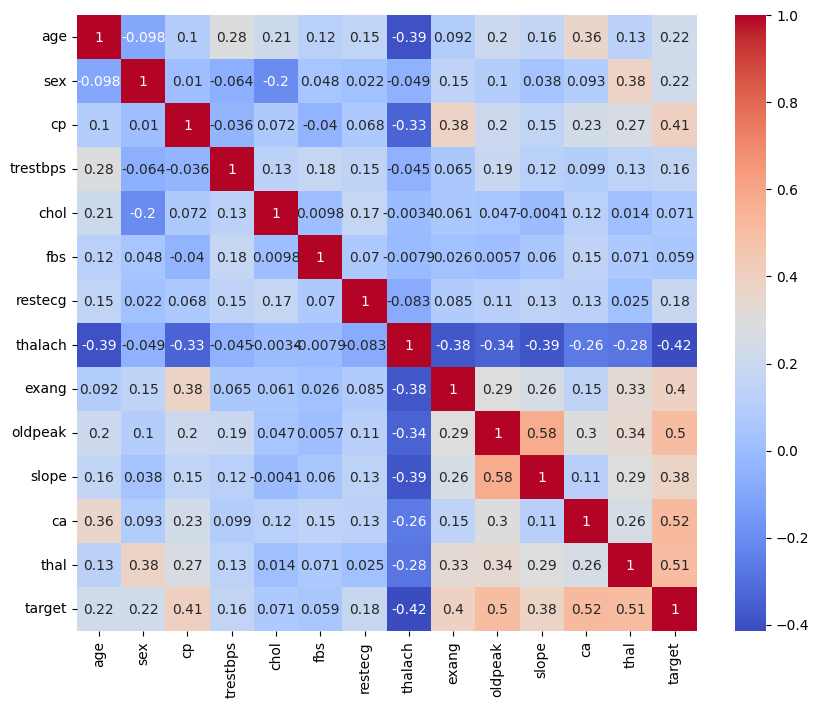

In [10]:
df = x.copy()
df["target"] = y

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [11]:
x.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [12]:
x=x.fillna(x.median())

In [13]:
x=pd.get_dummies(x, columns=['cp','restecg','slope','thal'])
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [14]:
y = (y > 0).astype(int)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=42
)


In [40]:
y_train

,num
124,1
72,1
15,0
10,0
163,0
...,...
188,1
71,1
106,1
270,1


In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

X_resampled.shape

(232, 22)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)


In [53]:

model = SVC(kernel="rbf", C=0.6, gamma="scale",class_weight='balanced',probability=True)
model.fit(X_resampled, y_resampled)

print(model.score(X_test, y_test))

0.8461538461538461


c:\Users\aashr\OneDrive\Desktop\HackShastra_Hackathon\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [54]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))


Train Accuracy: 0.8962264150943396
Test Accuracy: 0.8461538461538461


In [55]:
y_prob = model.predict_proba(X_test)

print(y_prob[:5])


[[0.49106317 0.50893683]
 [0.16258695 0.83741305]
 [0.09507105 0.90492895]
 [0.34508182 0.65491818]
 [0.07237624 0.92762376]]


In [56]:
risk = y_prob[:,1]


In [57]:
def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Moderate Risk"
    else:
        return "High Risk"


In [58]:
X_test

array([[-0.21308529,  0.70466812, -0.15600036, ...,  0.92503409,
        -0.25341701, -0.81781112],
       [-0.10061234,  0.70466812, -1.22924771, ...,  0.92503409,
        -0.25341701, -0.81781112],
       [ 0.12433354,  0.70466812, -0.4243122 , ...,  0.92503409,
        -0.25341701, -0.81781112],
       ...,
       [ 1.02411709,  0.70466812, -0.4243122 , ..., -1.08832396,
        -0.25341701,  1.23130902],
       [ 0.34927943,  0.70466812,  0.917247  , ..., -1.08832396,
        -0.25341701,  1.23130902],
       [ 0.34927943,  0.70466812, -1.49755955, ..., -1.08832396,
        -0.25341701,  1.23130902]], shape=(91, 22))

In [59]:
patient = X_test[0].reshape(1,-1)

prob = model.predict_proba(patient)[0][1]

print(f"Heart Disease Risk: {prob*100:.2f}%")


Heart Disease Risk: 50.89%


In [60]:
risk_level(prob)

'Moderate Risk'